In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
from collections import defaultdict

np.random.seed(0)
random.seed(0)

In [2]:
def initialize_graph(G, infected_prob):
    # assigning infected nodes
    for node in G.nodes:
        G.nodes[node]["infected"] = random.random() < infected_prob

def split_nodes(G):
    infected_nodes = []
    susceptible_nodes = []
    for node in G.nodes:
        if G.nodes[node]["infected"]:
            infected_nodes.append(node)
        else:
            susceptible_nodes.append(node)
    return infected_nodes, susceptible_nodes

def get_proportions(G):
    n = len(G.nodes)
    infected_nodes, susceptible_nodes = split_nodes(G)
    i = len(infected_nodes) / n
    s = 1 - i
    return i, s

def step(G, beta, gamma):
    infected_nodes, susceptible_nodes = split_nodes(G)
    
    # S -> I
    for node in susceptible_nodes:
        # there is at least one infected neighbor
        n_infected_neighbors = len([neighbor for neighbor in nx.neighbors(G, node) if G.nodes[neighbor]["infected"]])
        if n_infected_neighbors > 0:
            if random.random() < 1 - (1 - beta) ** n_infected_neighbors:
                G.nodes[node]["infected"] = True
    
    # I -> S
    for node in infected_nodes:
        if random.random() < gamma:
            G.nodes[node]["infected"] = False
            
def make_simulation(G, beta, gamma, time_steps):
    i_list = []
    s_list = []
    
    # initial fractions
    i0, s0 = get_proportions(G)
    i_list.append(i0)
    s_list.append(s0)
     
    for time in range(time_steps):
        step(G, beta, gamma)
        i, s = get_proportions(G)
        i_list.append(i)
        s_list.append(s)
    
    return i_list, s_list

def repeat_simulations(n_simulations, beta, gamma, time_steps, infected_prob, graph_gen_func, **kwargs):
    avg_i_list = np.zeros(time_steps + 1)
    avg_s_list = np.zeros(time_steps + 1)
    
    for i in range(n_simulations):
        G = graph_gen_func(**kwargs)
        initialize_graph(G, infected_prob)
        i_list, s_list = make_simulation(G, beta, gamma, time_steps)
        
        avg_i_list = avg_i_list + np.array(i_list)
        avg_s_list = avg_s_list + np.array(s_list)
        
    avg_i_list /= n_simulations
    avg_s_list /= n_simulations
    
    return avg_i_list, avg_s_list

def repeat_simulations2(n_simulations, beta, gamma, time_steps, infected_prob, graph_gen_func, **kwargs):
    total_k_avg = defaultdict(int)
    infected_k_avg = defaultdict(int)
    
    for _ in range(n_simulations):
        G = graph_gen_func(**kwargs)
        initialize_graph(G, infected_prob)
        _ = make_simulation(G, beta, gamma, time_steps)
    
        for node in G.nodes:
            k = G.degree[node]
            total_k_avg[k] += 1
            if G.nodes[node]["infected"]:
                infected_k_avg[k] += 1
    
    k_max = max(total_k_avg.keys())
    k_full = np.arange(0, k_max + 1)
    
    ik_sim_full = np.zeros_like(k_full, dtype=float)
    
    for k in k_full:
        if total_k_avg[k] > 0:
            ik_sim_full[k] = infected_k_avg[k] / total_k_avg[k]
        else:
            ik_sim_full[k] = 0.0
    
    return k_full, ik_sim_full

## Task 1 - SIS model on ER graph

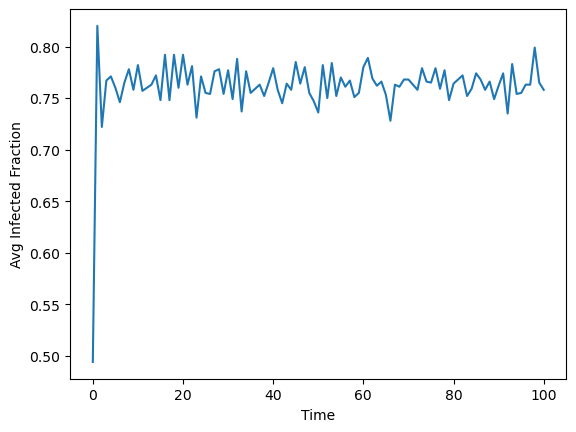

In [3]:
n = 100
p = 0.2
infected_prob = 0.5
beta = 0.2 # prob S -> I
gamma = 0.3 # prob I -> S
lmbda = beta / gamma
n_simulations = 10
time_steps = 100

avg_i_list, avg_s_list = repeat_simulations(n_simulations, beta, gamma, time_steps, infected_prob, nx.erdos_renyi_graph, n=n, p=p)
plt.plot(np.arange(time_steps+1), avg_i_list)
plt.xlabel('Time')
plt.ylabel('Avg Infected Fraction')
plt.show()

In [4]:
n = 100
p = 0.2
infected_prob = 0.5
n_simulations = 20
time_steps = 1000

In [5]:
# epidemic threshold
k_avg = p * (n - 1)
lmbda_c = 1 / k_avg
lambda_c_sf = k_avg / (k_avg + k_avg ** 2)

In [6]:
beta_list = np.linspace(0.001, 0.03, 30)
gamma = 0.5
lmbda_list = beta_list / gamma
print(lmbda_list)

[0.002 0.004 0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02  0.022 0.024
 0.026 0.028 0.03  0.032 0.034 0.036 0.038 0.04  0.042 0.044 0.046 0.048
 0.05  0.052 0.054 0.056 0.058 0.06 ]


In [7]:
infected_list = []

for beta in beta_list:
    avg_i_list, avg_s_list = repeat_simulations(n_simulations, beta, gamma, time_steps, infected_prob, nx.erdos_renyi_graph, n=n, p=p)
    infected_list.append(avg_i_list[-1])

In [8]:
expected_i = np.clip(1 - gamma / (k_avg * beta_list), 0, 1)

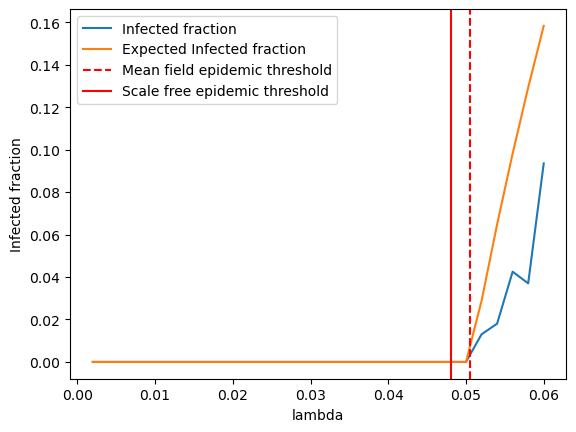

In [9]:
plt.plot(lmbda_list, infected_list)
plt.plot(lmbda_list, expected_i)
plt.xlabel('lambda')
plt.ylabel('Infected fraction')
plt.axvline(lmbda_c, linestyle='--', color='r')
plt.axvline(lambda_c_sf, linestyle='-', color='r')
plt.legend(['Infected fraction', 'Expected Infected fraction', 'Mean field epidemic threshold', 'Scale free epidemic threshold'])
plt.show()

In [10]:
n_simulations = 1000
time_steps = 1000
n = 100
p = 0.2
infected_prob = 0.5
beta = 0.03
gamma = 0.3
lmbda = beta / gamma

k_full, ik_sim_full = repeat_simulations2(n_simulations, beta, gamma, time_steps, infected_prob, nx.erdos_renyi_graph, n=n, p=p)

QI = np.mean(ik_sim_full * k_full) / np.mean(k_full)

ik_exp_full = (lmbda * k_full * QI) / (1 + lmbda * k_full * QI)

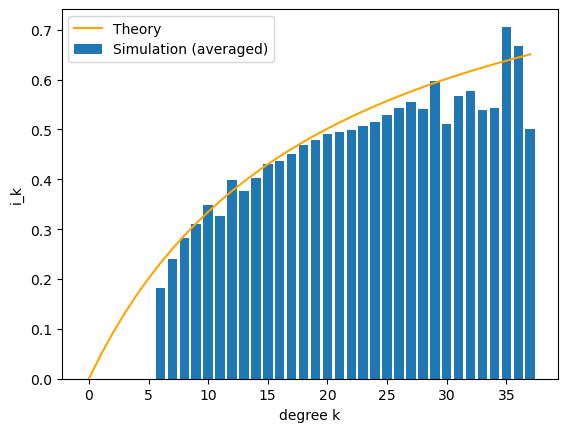

In [11]:
plt.bar(
    k_full,
    ik_sim_full,
    label="Simulation (averaged)"
)

plt.plot(
    k_full,
    ik_exp_full,
    color="orange",
    label="Theory"
)

plt.xlabel("degree k")
plt.ylabel("i_k")
plt.legend()
plt.show()

## Task 2 - SIS model on BA networks

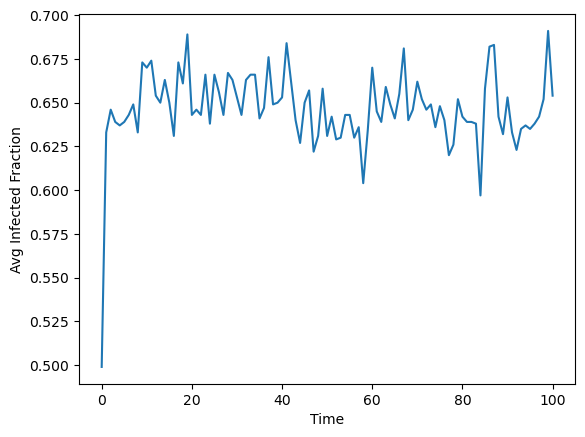

In [12]:
n = 100
m = 3
infected_prob = 0.5
beta = 0.2
gamma = 0.3
lmbda = beta / gamma

G = nx.barabasi_albert_graph(n=n, m=m)
initialize_graph(G, infected_prob)

n_simulations = 10
time_steps = 100

avg_i_list, avg_s_list = repeat_simulations(n_simulations, beta, gamma, time_steps, infected_prob, nx.barabasi_albert_graph, n=n, m=m)
plt.plot(np.arange(time_steps+1), avg_i_list)
plt.xlabel('Time')
plt.ylabel('Avg Infected Fraction')
plt.show()

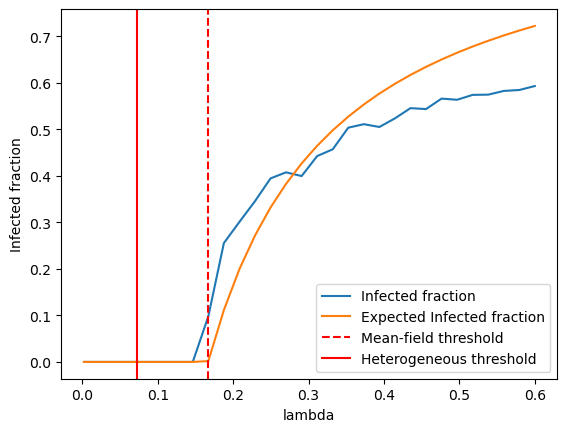

In [13]:
n = 100
m = 3
infected_prob = 0.5
n_simulations = 20
time_steps = 1000

k_avg = 2 * m
k2_avg = 2 * m**2 * np.log(n)
lmbda_c = 1 / k_avg
lambda_c_sf = k_avg / k2_avg

beta_list = np.linspace(0.001, 0.3, 30)
gamma = 0.5
lmbda_list = beta_list / gamma
infected_list = []

for beta in beta_list:
    avg_i_list, avg_s_list = repeat_simulations(
        n_simulations, beta, gamma, time_steps, infected_prob,
        nx.barabasi_albert_graph, n=n, m=m
    )
    infected_list.append(avg_i_list[-1])

expected_i = np.clip(1 - gamma / (k_avg * beta_list), 0, 1)

plt.plot(lmbda_list, infected_list)
plt.plot(lmbda_list, expected_i)
plt.xlabel('lambda')
plt.ylabel('Infected fraction')
plt.axvline(lmbda_c, linestyle='--', color='r')
plt.axvline(lambda_c_sf, linestyle='-', color='r')
plt.legend(['Infected fraction', 'Expected Infected fraction', 
            'Mean-field threshold', 'Heterogeneous threshold'])
plt.show()

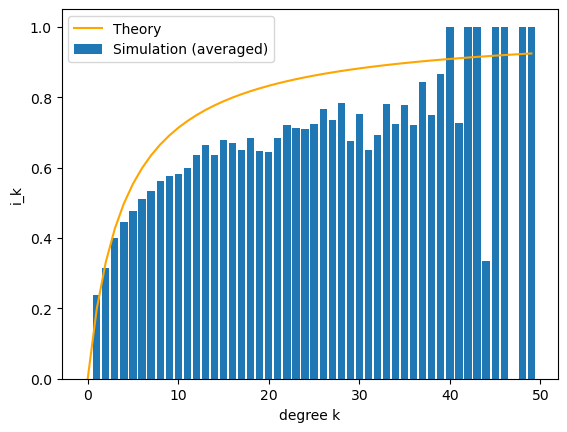

In [14]:
n_simulations = 1000
time_steps = 1000
n = 100
m = 3
infected_prob = 0.5
beta = 0.1
gamma = 0.3
lmbda = beta / gamma

k_full, ik_sim_full = repeat_simulations2(
    n_simulations, beta, gamma, time_steps, infected_prob,
    nx.barabasi_albert_graph, n=n, m=m
)

QI = np.mean(ik_sim_full * k_full) / np.mean(k_full)

ik_exp_full = (lmbda * k_full * QI) / (1 + lmbda * k_full * QI)

plt.bar(
    k_full,
    ik_sim_full,
    label="Simulation (averaged)"
)

plt.plot(
    k_full,
    ik_exp_full,
    color="orange",
    label="Theory"
)

plt.xlabel("degree k")
plt.ylabel("i_k")
plt.legend()
plt.show()

## Task 3 - SIR model

In [15]:
def initialize_graph_SIR(G, infected_prob):
    for node in G.nodes:
        r = random.random()
        if r < infected_prob:
            G.nodes[node]["state"] = "I"
        else:
            G.nodes[node]["state"] = "S"

def split_nodes_SIR(G):
    infected_nodes = []
    susceptible_nodes = []
    recovered_nodes = []
    for node in G.nodes:
        state = G.nodes[node]["state"]
        if state == "I":
            infected_nodes.append(node)
        elif state == "S":
            susceptible_nodes.append(node)
        else:
            recovered_nodes.append(node)
    return susceptible_nodes, infected_nodes, recovered_nodes

def get_proportions_SIR(G):
    n = len(G.nodes)
    susceptible_nodes, infected_nodes, recovered_nodes = split_nodes_SIR(G)
    s = len(susceptible_nodes) / n
    i = len(infected_nodes) / n
    r = len(recovered_nodes) / n
    return s, i, r

def step_SIR(G, beta, gamma):
    susceptible_nodes, infected_nodes, recovered_nodes = split_nodes_SIR(G)
    
    # S -> I
    new_infected = []
    for node in susceptible_nodes:
        infected_neighbors = [nbr for nbr in nx.neighbors(G, node) if G.nodes[nbr]["state"] == "I"]
        n_infected_neighbors = len(infected_neighbors)
        if n_infected_neighbors > 0:
            if random.random() < 1 - (1 - beta) ** n_infected_neighbors:
                new_infected.append(node)
    
    # I -> R
    new_recovered = []
    for node in infected_nodes:
        if random.random() < gamma:
            new_recovered.append(node)
    
    # Update states
    for node in new_infected:
        G.nodes[node]["state"] = "I"
    for node in new_recovered:
        G.nodes[node]["state"] = "R"

def make_simulation_SIR(G, beta, gamma, time_steps):
    s_list, i_list, r_list = [], [], []
    
    s0, i0, r0 = get_proportions_SIR(G)
    s_list.append(s0)
    i_list.append(i0)
    r_list.append(r0)
    
    for t in range(time_steps):
        step_SIR(G, beta, gamma)
        s, i, r = get_proportions_SIR(G)
        s_list.append(s)
        i_list.append(i)
        r_list.append(r)
    
    return s_list, i_list, r_list

def repeat_simulations_SIR(n_simulations, beta, gamma, time_steps, infected_prob, graph_gen_func, **kwargs):
    avg_s, avg_i, avg_r = np.zeros(time_steps + 1), np.zeros(time_steps + 1), np.zeros(time_steps + 1)
    
    for _ in range(n_simulations):
        G = graph_gen_func(**kwargs)
        initialize_graph_SIR(G, infected_prob)
        s_list, i_list, r_list = make_simulation_SIR(G, beta, gamma, time_steps)
        
        avg_s += np.array(s_list)
        avg_i += np.array(i_list)
        avg_r += np.array(r_list)
    
    avg_s /= n_simulations
    avg_i /= n_simulations
    avg_r /= n_simulations
    
    return avg_s, avg_i, avg_r

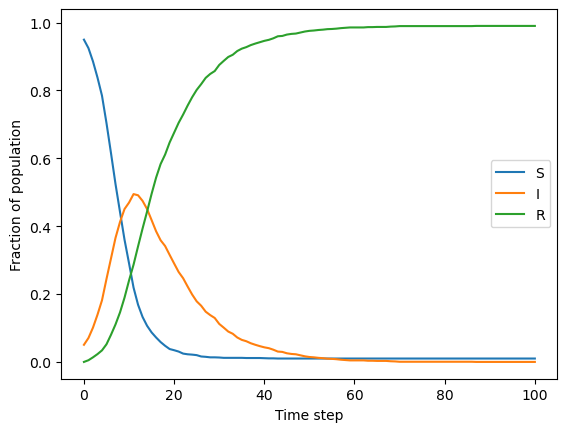

In [16]:
n = 100
p = 0.2
infected_prob = 0.05
n_simulations = 20
time_steps = 100
beta = 0.03
gamma = 0.1

avg_s, avg_i, avg_r = repeat_simulations_SIR(
    n_simulations, beta, gamma, time_steps, infected_prob, nx.erdos_renyi_graph, n=n, p=p
)

plt.plot(avg_s, label="S")
plt.plot(avg_i, label="I")
plt.plot(avg_r, label="R")
plt.xlabel("Time step")
plt.ylabel("Fraction of population")
plt.legend()
plt.show()

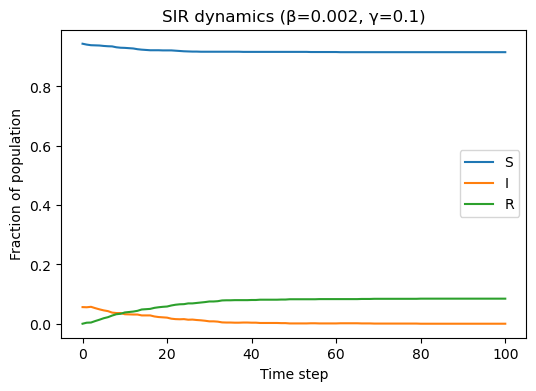

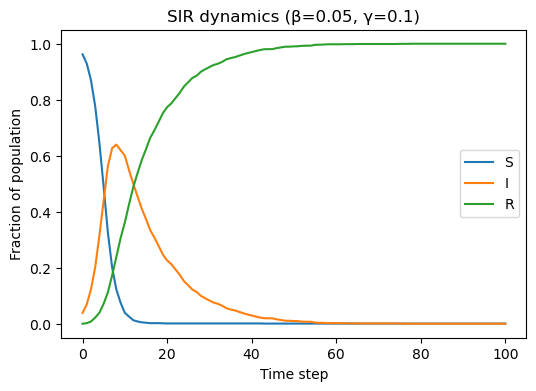

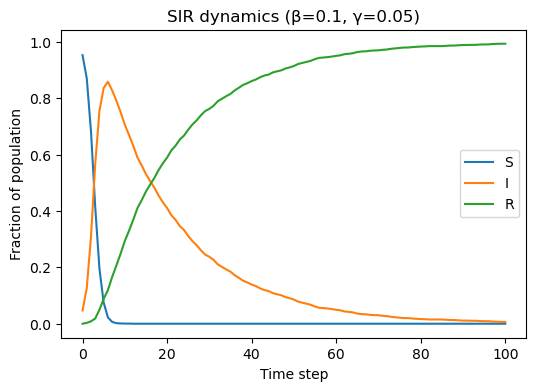

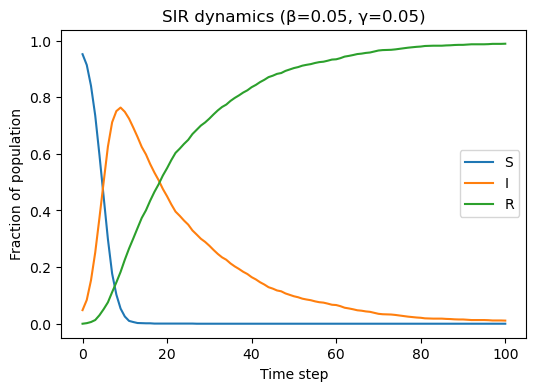

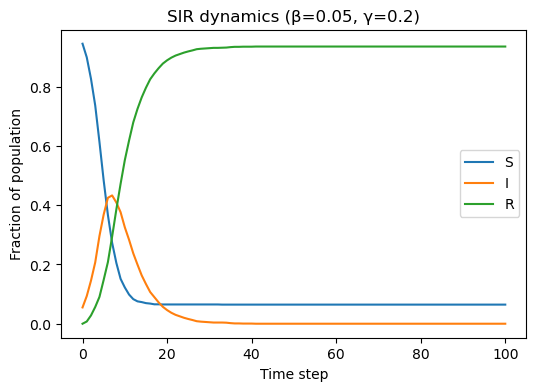

In [17]:
param_list = [
    (0.002, 0.1),
    (0.05, 0.1),
    (0.1, 0.05),
    (0.05, 0.05),
    (0.05, 0.2),
]

for beta, gamma in param_list:
    avg_s, avg_i, avg_r = repeat_simulations_SIR(
        n_simulations, beta, gamma, time_steps, infected_prob, nx.erdos_renyi_graph, n=n, p=p
    )
    
    plt.figure(figsize=(6,4))
    plt.plot(avg_s, label="S")
    plt.plot(avg_i, label="I")
    plt.plot(avg_r, label="R")
    plt.xlabel("Time step")
    plt.ylabel("Fraction of population")
    plt.title(f"SIR dynamics (β={beta}, γ={gamma})")
    plt.legend()
    plt.show()

In [31]:
def initialize_voter(G, ideology=False):
    for node in G.nodes:
        G.nodes[node]["S"] = random.choice([-1, 1])
        if ideology:
            # assign intrinsic ideology b_i in [-1, 1]
            G.nodes[node]["ideology"] = random.uniform(-1, 1)

def step_modified_voter(G, alpha=0.0, h=0.0, beta=0.0):
    node = random.choice(list(G.nodes))
    S_i = G.nodes[node]["S"]
    
    neighbors = list(G.neighbors(node))
    m_i = sum(G.nodes[n]["S"] for n in neighbors)
    
    b_i = G.nodes[node]["ideology"] if "ideology" in G.nodes[node] else 0
    
    effective_field = m_i + alpha * h + beta * b_i
    G.nodes[node]["S"] = 1 if effective_field > 0 else -1 if effective_field < 0 else S_i

def run_simulation_voter(G, steps=1000, alpha=0.0, h=0.0, beta=0.0):
    history = []
    for _ in range(steps):
        step_modified_voter(G, alpha, h, beta)
        avg_opinion = np.mean([G.nodes[n]["S"] for n in G.nodes])
        history.append(avg_opinion)
    return history

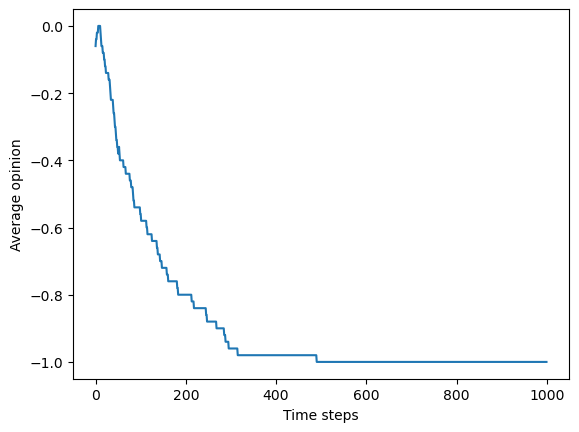

In [39]:
G = nx.erdos_renyi_graph(n=n, p=p)
initialize_voter(G, ideology=False)
history = run_simulation_voter(G)

plt.plot(history)
plt.xlabel("Time steps")
plt.ylabel("Average opinion")
plt.show()